# MomentRFI on MeerKLASS — parameter study

**Observation ID:** `1762283663` &nbsp; • &nbsp; **Env:** `conda activate rfi_flagger`
&nbsp; • &nbsp; **Source dump:** `/Users/zzhang/Dataspace/MeerKLASS/1762283663/aoflagger_plugin.pickle` (40 GB)

The goal of this notebook is to see **how `MomentRFI` behaves under
different setups and parameter values** on real MeerKLASS waterfall data.
We load the AOflagger-stage pipeline dump, pick two contrasting receivers
(healthy `m000h`, stressed `m034h`), and then run a sequence of parameter
sweeps on `IterativeSurfaceFitter`:

1. `sigma_threshold` — clipping stringency
2. Noise estimator (`mad` vs `lower_tail`)
3. Phase 2 on vs off (Phase 1 only)
4. `smooth_mask` post-processing kernel

Only the **last section** compares `MomentRFI` outputs against the MeerKLASS
first-round AOflagger mask.


## 1. Imports & configuration

In [1]:
import pickle
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sys
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from MomentRFI import IterativeSurfaceFitter, validate_waterfall, smooth_mask
from MomentRFI.plotting import plot_summary

from museek.enums.result_enum import ResultEnum
from museek.receiver import Receiver

print("MomentRFI repo root :", REPO_ROOT)


MomentRFI repo root : /Users/zzhang/Workspace/RadioCosmology/MomentRFI


In [2]:
DATA_DIR  = Path("/Users/zzhang/Dataspace/MeerKLASS/1762283663")
DUMP_PATH = DATA_DIR / "aoflagger_plugin.pickle"
assert DUMP_PATH.exists(), f"missing: {DUMP_PATH}"
print(f"file size : {DUMP_PATH.stat().st_size / 1024**3:6.2f} GiB")


file size :  39.60 GiB


## 2. Load the museek context dump

> **RAM note.** The file is ~40 GB on disk; expect peak memory near that
> size during load. Run on a machine with ≥ 64 GB RAM, or slice the file
> on another host first.

The dump is an `ivory.Context` (dict-like) keyed by `museek.enums.ResultEnum`.
Each value is a `Result` whose `.result` attribute holds the payload.

In [3]:
with open(DUMP_PATH, "rb") as f:
    context = pickle.load(f)

print(f"{len(context)} entries in the context:")
for key in context:
    print(f"  {key}")


18 entries in the context:
  loop: {
museek.plugin.in_plugin
museek.plugin.noise_diode_flagger_plugin
museek.plugin.known_rfi_plugin
museek.plugin.rawdata_flagger_plugin
museek.plugin.scan_track_split_plugin
museek.plugin.point_source_flagger_plugin
museek.plugin.aoflagger_plugin
museek.plugin.aoflagger_secondrun_plugin
museek.plugin.antenna_flagger_plugin
museek.plugin.noise_diode_plugin
museek.plugin.gain_calibration_plugin
museek.plugin.aoflagger_postcalibration_plugin
hash 8774340618228
}
  params
  plugins
  timings
  ContextStorageEnum.FILE_NAME
  ContextStorageEnum.DIRECTORY
  ResultEnum.FLAG_REPORT_WRITER
  ResultEnum.DATA
  ResultEnum.RECEIVERS
  ResultEnum.OBSERVATION_DATE
  ResultEnum.BLOCK_NAME
  ResultEnum.OUTPUT_PATH
  ResultEnum.FLAG_NAME_LIST
  ResultEnum.SCAN_DATA
  ResultEnum.TRACK_DATA
  ResultEnum.SCAN_OBSERVATION_START
  ResultEnum.SCAN_OBSERVATION_END
  ResultEnum.POINT_SOURCE_FLAG


## 3. Schema walkthrough

The entry we care about is `ResultEnum.SCAN_DATA`, a `TimeOrderedData` (TOD)
bundle:

```
context[ResultEnum.SCAN_DATA].result  →  TimeOrderedData
 ├── .visibility    DataElement   (n_dump, n_freq, n_receiver)
 ├── .flags         FlagList      (n_flags, n_dump, n_freq, n_receiver)
 │                  .combine(threshold=1) → FlagElement (n_dump, n_freq, n_receiver)
 ├── .frequencies   DataElement   .squeeze → (n_freq,)  [Hz]
 ├── .timestamps    DataElement   .squeeze → (n_dump,)  [Unix s]
 ├── .receivers     list[Receiver]   ("m000h"-style names)
 └── .antennas      list[Antenna]
```

`FlagList.combine(threshold=1)` OR-reduces the sub-masks into the pipeline's
effective AOflagger-stage mask.

In [4]:
scan_data = context[ResultEnum.SCAN_DATA].result

visib_all = scan_data.visibility.array                        # (n_dump, n_freq, n_receiver)
flags_all = scan_data.flags.combine(threshold=1).array        # (n_dump, n_freq, n_receiver)
freqs_hz  = np.asarray(scan_data.frequencies.squeeze)         # (n_freq,)
times_s   = np.asarray(scan_data.timestamps.squeeze)          # (n_dump,)

print("visibility dtype :", visib_all.dtype, "  shape :", visib_all.shape)
print("flags      dtype :", flags_all.dtype, "  shape :", flags_all.shape)
print("n_dump  =", visib_all.shape[0])
print("n_freq  =", visib_all.shape[1], f"  ({freqs_hz[0]/1e6:.2f} – {freqs_hz[-1]/1e6:.2f} MHz)")
print("n_recv  =", visib_all.shape[2])
print("time    :", times_s[0], "→", times_s[-1], f" ({(times_s[-1]-times_s[0])/60:.1f} min)")
print()
print("first receivers :", [r.name for r in scan_data.receivers[:6]])


visibility dtype : float64   shape : (3142, 4096, 118)
flags      dtype : bool   shape : (3142, 4096, 118)
n_dump  = 3142
n_freq  = 4096   (544.00 – 1087.87 MHz)
n_recv  = 118
time    : 1762285165.5337112 → 1762291671.5006044  (108.4 min)

first receivers : ['m000h', 'm000v', 'm001h', 'm001v', 'm002h', 'm002v']


## 4. Pick two contrasting receivers

Quick bar chart of per-receiver AOflagger flag fractions (live version of
`flag_report.md`) to motivate the pair we study: a healthy dish/pol and a
heavily-flagged outlier (skipping the 100 %-flagged dead `m010`).

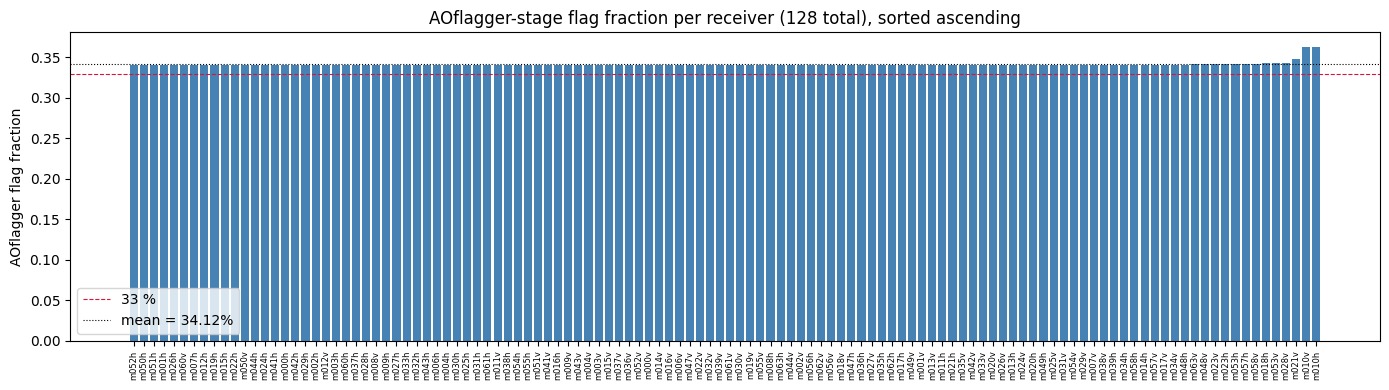

healthy reference : m000h  (AOflagger frac = 34.05%)
stressed outlier  : m034h  (AOflagger frac = 34.10%)


In [5]:
ao_frac = flags_all.mean(axis=(0, 1))
recv_names = np.array([r.name for r in scan_data.receivers])
order = np.argsort(ao_frac)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(np.arange(len(ao_frac)), ao_frac[order], color="steelblue")
ax.set_xticks(np.arange(len(ao_frac)))
ax.set_xticklabels(recv_names[order], rotation=90, fontsize=6)
ax.axhline(0.33, ls="--", color="crimson", lw=0.8, label="33 %")
ax.axhline(ao_frac.mean(), ls=":", color="black", lw=0.8, label=f"mean = {ao_frac.mean():.2%}")
ax.set_ylabel("AOflagger flag fraction")
ax.set_title("AOflagger-stage flag fraction per receiver (128 total), sorted ascending")
ax.legend()
plt.tight_layout()
plt.show()

NAME_A, NAME_B = "m000h", "m034h"
print(f"healthy reference : {NAME_A}  (AOflagger frac = {ao_frac[list(recv_names).index(NAME_A)]:.2%})")
print(f"stressed outlier  : {NAME_B}  (AOflagger frac = {ao_frac[list(recv_names).index(NAME_B)]:.2%})")


## 5. Helpers

- `receiver_index_of(name)` — look up a receiver by its `"m000h"`-style name.
- `prepare_waterfall(i)` — slice out one receiver, take the amplitude, and
  apply the **positivity guard**. `MomentRFI` fits in `log10` space, so it
  needs strictly positive pixels; any ≤ 0 value is replaced by `eps` and
  folded into the AOflagger mask we carry alongside.
- `run_scenario(wf, **overrides)` — fit once with a set of
  `IterativeSurfaceFitter` overrides and return `(fitter, mask)`.
- `mask_frac(m)` and `iou(a, b)` — compact stats.

In [6]:
def receiver_index_of(name):
    target = Receiver.from_string(name)
    for i, r in enumerate(scan_data.receivers):
        if r == target:
            return i
    raise ValueError(f"receiver {name!r} not found")


def prepare_waterfall(i, eps=1e-30):
    raw = visib_all[:, :, i]
    if np.iscomplexobj(raw):
        wf = np.abs(raw).astype(np.float64, copy=False)
    else:
        wf = raw.astype(np.float64, copy=True)
    ao = flags_all[:, :, i].astype(bool, copy=True)
    bad = ~(wf > 0)
    wf[bad] = eps
    ao |= bad
    return wf, ao


def run_scenario(wf, prior_mask=None, **overrides):
    fitter = IterativeSurfaceFitter(verbose=False, **overrides)
    mask = fitter.fit(wf, prior_mask=prior_mask)
    return fitter, mask


def mask_frac(m):
    return m.mean()


def iou(a, b):
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union else 0.0


def plot_mask_grid(masks, labels, freqs_mhz, suptitle, ncols=None):
    """Side-by-side imshow of several boolean masks."""
    n = len(masks)
    ncols = ncols or n
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.2 * ncols, 3.6 * nrows),
                             sharey=True, squeeze=False)
    extent = [freqs_mhz[0], freqs_mhz[-1], masks[0].shape[0], 0]
    for k, (m, lbl) in enumerate(zip(masks, labels)):
        ax = axes[k // ncols][k % ncols]
        ax.imshow(m, aspect="auto", cmap="Reds",
                  extent=extent, interpolation="nearest", vmin=0, vmax=1)
        ax.set_title(f"{lbl}\nfrac = {mask_frac(m):.2%}")
        ax.set_xlabel("Frequency [MHz]")
    for k in range(n, nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")
    axes[0][0].set_ylabel("Time dump")
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


## 6. Baseline: default MomentRFI on `m000h`

Everything that follows is perturbations around this reference point.
Default parameters:
`sigma_threshold=4.0`, `phase1_degree=5`, `phase2_degree_freq=10`,
`phase2_degree_time=5`, `noise_estimator="mad"`,
`sigma_floor_factor=1.0`, `max_iterations=15`.

In [7]:
i_a = receiver_index_of(NAME_A)
wf_a, ao_a = prepare_waterfall(i_a)

print("validate_waterfall :", validate_waterfall(wf_a))

fit_default_a, mask_default_a = run_scenario(wf_a)

print(f"\nsigma_floor              = {fit_default_a.sigma_floor:.4f}")
print(f"phase 1 / phase 2 iters   = "
      f"{len(fit_default_a.history['phase1'])} / {len(fit_default_a.history['phase2'])}")
print(f"flag fraction            = {mask_frac(mask_default_a):.2%}")

# Store every scenario here so the final section can reuse them.
scenarios_a = {"default": mask_default_a}


validate_waterfall : {'shape': (3142, 4096), 'min': 1.0990098714828491, 'max': 16194.2236328125, 'has_nan': False, 'has_zero': False, 'has_negative': False}



sigma_floor              = 0.1437
phase 1 / phase 2 iters   = 3 / 5
flag fraction            = 0.82%


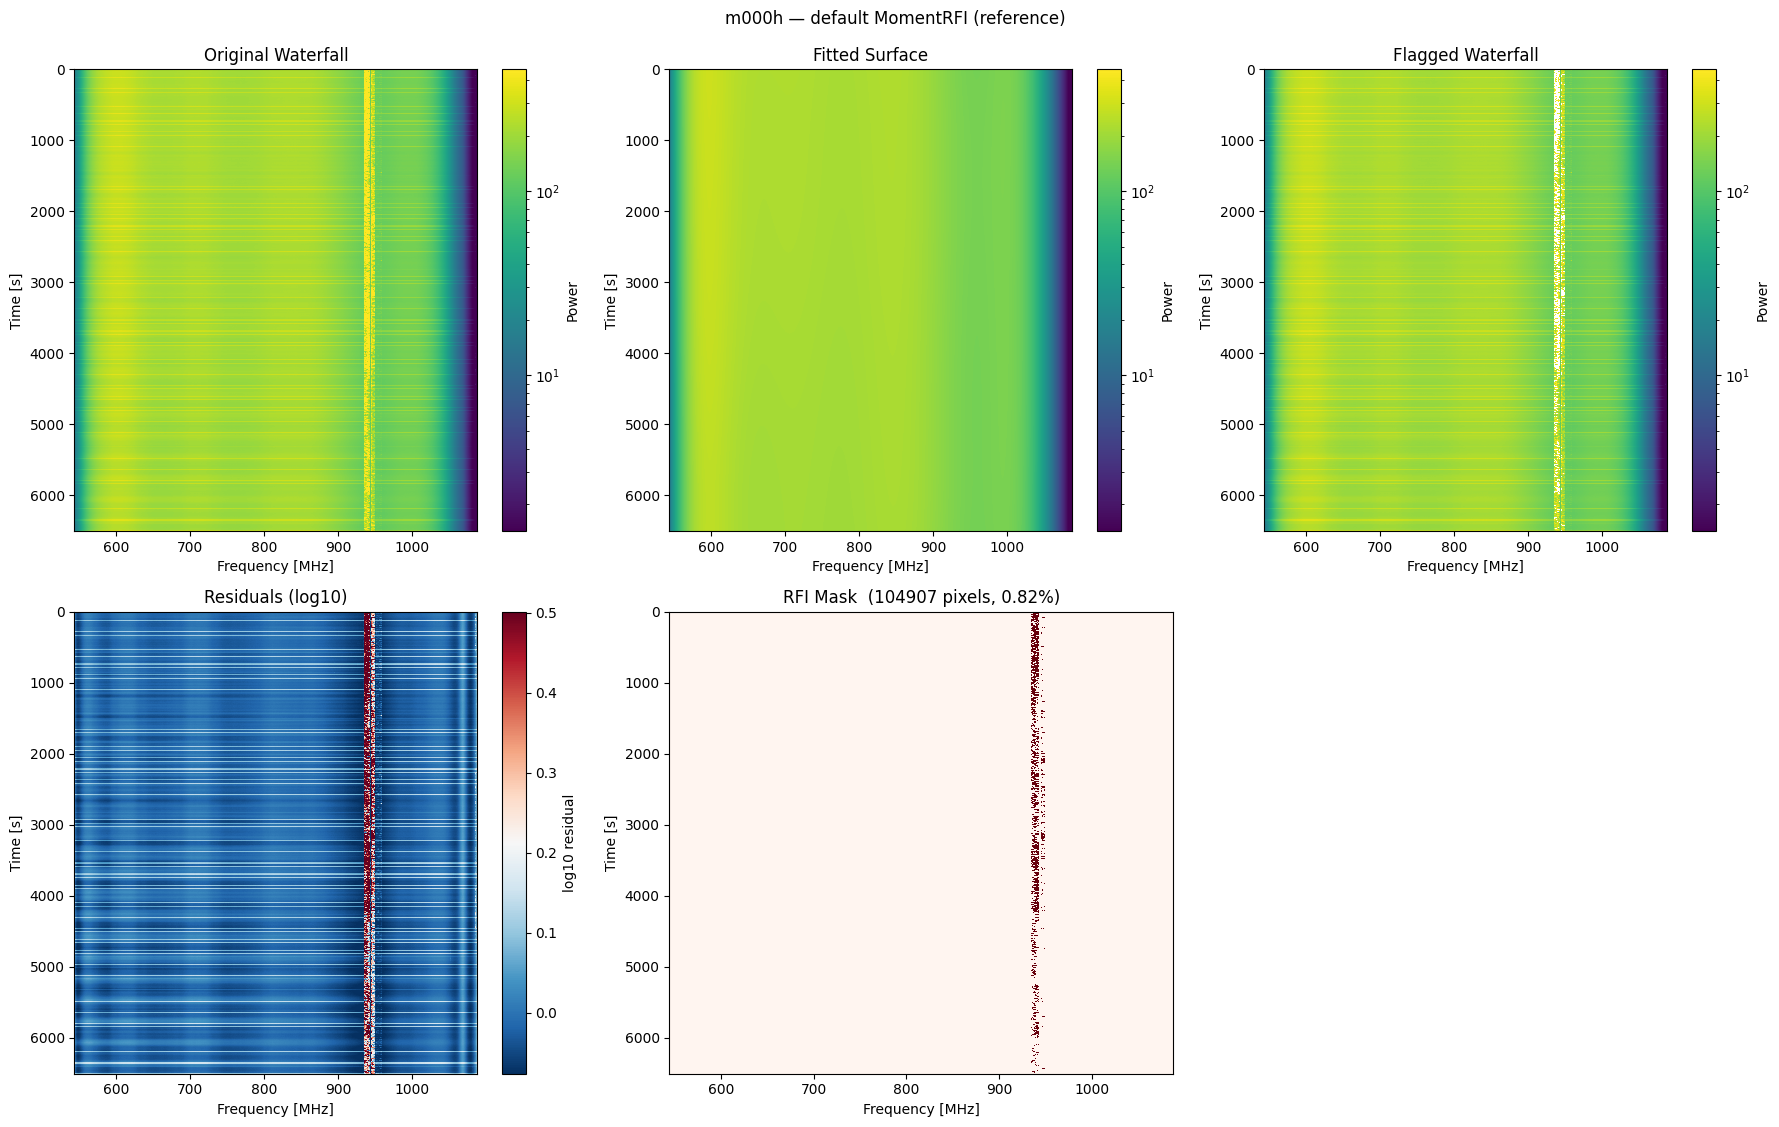

In [8]:
plot_summary(wf_a, fit_default_a, freqs=freqs_hz / 1e6, times=times_s - times_s[0])
plt.suptitle(f"{NAME_A} — default MomentRFI (reference)", y=1.02)
plt.show()


## 7. Sweep — `sigma_threshold` (aggressive regime)

`sigma_threshold` is the number of residual standard deviations above the
fitted surface a pixel must exceed to be flagged. **Lower values are more
aggressive** (easier to call a pixel RFI). We sweep `σ ∈ [1.0, 4.0]`
to emphasise the aggressive regime — past runs showed MomentRFI flags a
strict subset of AOflagger at default `σ = 4.0`, so the question is how
far we need to lower `σ` before MomentRFI starts recovering a meaningful
fraction of AOflagger's mask (and eventually starts flagging pixels AO did
not).

Alongside flag fraction we plot two tradeoff curves against the AOflagger
reference mask:

- **recall vs AO** = `|MRFI ∩ AO| / |AO|` — what fraction of AO-flagged
  pixels does MomentRFI independently catch?
- **precision vs AO** = `|MRFI ∩ AO| / |MRFI|` — what fraction of
  MomentRFI's flags does AO agree with?

The Phase 1 `sigma_floor` prevents runaway flagging even at `σ = 1.0`.

In [9]:
sigma_grid = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
sigma_results = {}
for s in sigma_grid:
    _, m = run_scenario(wf_a, sigma_threshold=s)
    sigma_results[f"σ = {s}"] = m
    inter = (m & ao_a).sum()
    recall = inter / ao_a.sum() if ao_a.any() else 0.0
    prec   = inter / m.sum() if m.any() else 0.0
    print(f"σ = {s:>3.1f}  frac = {mask_frac(m):.2%}   "
          f"recall = {recall:.2%}   precision = {prec:.2%}")

# Record extremes for the final comparison.
scenarios_a["aggressive (σ=1.0)"]   = sigma_results["σ = 1.0"]
scenarios_a["conservative (σ=4.0)"] = sigma_results["σ = 4.0"]


σ = 1.0  frac = 13.22%   recall = 38.83%   precision = 100.00%


σ = 1.5  frac = 16.94%   recall = 45.92%   precision = 92.28%


σ = 2.0  frac = 5.74%   recall = 16.87%   precision = 100.00%


σ = 2.5  frac = 1.96%   recall = 5.77%   precision = 100.00%


σ = 3.0  frac = 1.70%   recall = 4.98%   precision = 100.00%


σ = 3.5  frac = 1.40%   recall = 4.10%   precision = 100.00%


σ = 4.0  frac = 0.82%   recall = 2.39%   precision = 100.00%


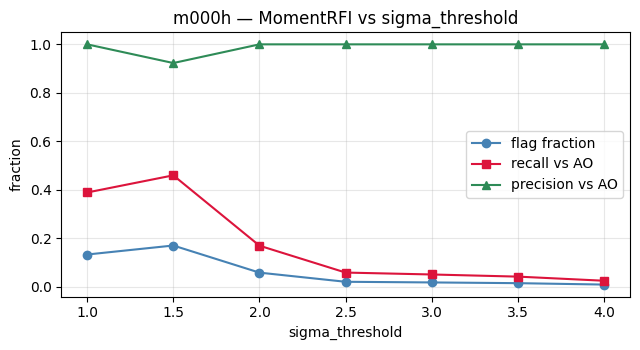

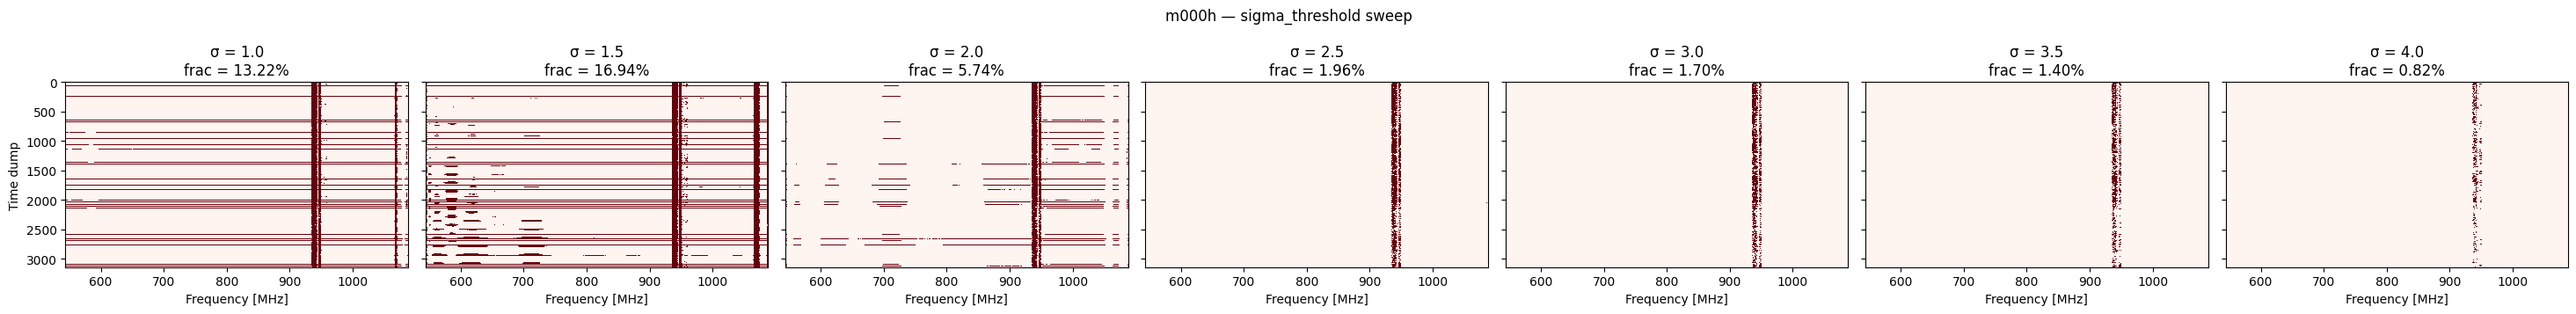

In [10]:
# Tradeoff curves vs sigma
fracs   = np.array([mask_frac(sigma_results[f"σ = {s}"]) for s in sigma_grid])
recalls = np.array([(sigma_results[f"σ = {s}"] & ao_a).sum() / ao_a.sum()
                    for s in sigma_grid])
precs   = np.array([(sigma_results[f"σ = {s}"] & ao_a).sum()
                    / max(1, sigma_results[f"σ = {s}"].sum()) for s in sigma_grid])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(sigma_grid, fracs,   "o-", label="flag fraction",       color="steelblue")
ax.plot(sigma_grid, recalls, "s-", label="recall vs AO",        color="crimson")
ax.plot(sigma_grid, precs,   "^-", label="precision vs AO",     color="seagreen")
ax.set_xlabel("sigma_threshold")
ax.set_ylabel("fraction")
ax.set_title(f"{NAME_A} — MomentRFI vs sigma_threshold")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

plot_mask_grid(list(sigma_results.values()), list(sigma_results.keys()),
               freqs_hz / 1e6,
               suptitle=f"{NAME_A} — sigma_threshold sweep",
               ncols=len(sigma_grid))


## 8. Sweep — noise estimator

`noise_estimator="mad"` (default) uses the Median Absolute Deviation on the
log-space residuals — robust up to ~50 % contamination. `lower_tail` fits a
Gaussian to the lower `lower_tail_fraction` of the residual distribution,
which is more reliable **above** ~50 % contamination (heavy RFI).

mad (default)           flag fraction = 0.82%
lower_tail (0.2)        flag fraction = 0.46%


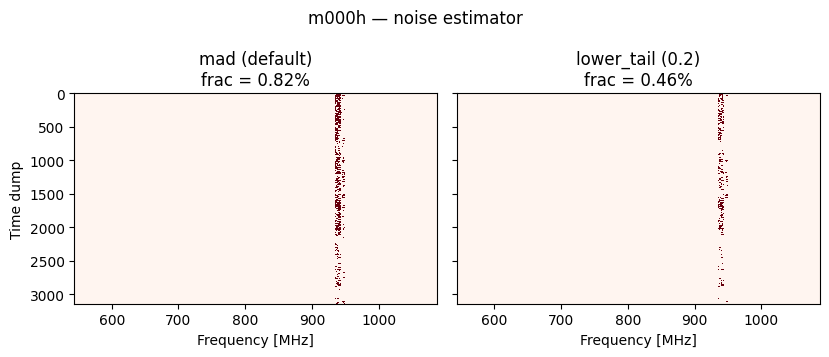

In [11]:
noise_results = {
    "mad (default)":         run_scenario(wf_a, noise_estimator="mad")[1],
    "lower_tail (0.2)":      run_scenario(wf_a, noise_estimator="lower_tail",
                                          lower_tail_fraction=0.2)[1],
}
for lbl, m in noise_results.items():
    print(f"{lbl:<22s}  flag fraction = {mask_frac(m):.2%}")

plot_mask_grid(list(noise_results.values()), list(noise_results.keys()),
               freqs_hz / 1e6, suptitle=f"{NAME_A} — noise estimator")


## 9. Sweep — Phase 2 on vs off

Setting `phase2_degree_freq=None` and `phase2_degree_time=None` **disables
Phase 2 entirely**: only the low-order Phase 1 isotropic fit is used, and
the sigma floor is the sigma used for clipping. This is a diagnostic
scenario — how much of the flagging comes from Phase 1 alone?

Phase 1 only           flag fraction = 0.47%
default (Phase 1 + 2)  flag fraction = 0.82%


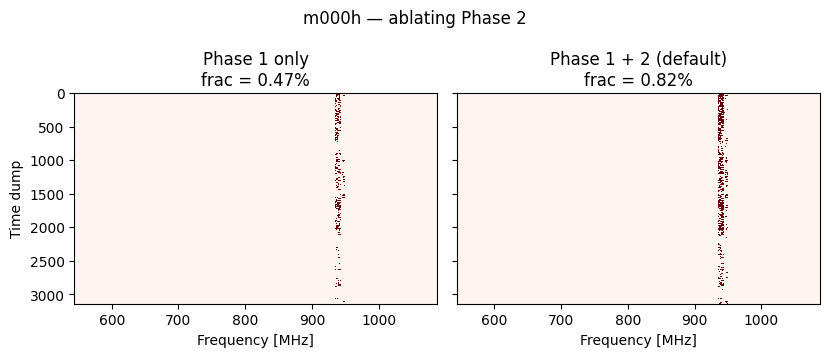

In [12]:
p1only_fitter, p1only_mask = run_scenario(
    wf_a, phase2_degree_freq=None, phase2_degree_time=None,
)
print(f"Phase 1 only           flag fraction = {mask_frac(p1only_mask):.2%}")
print(f"default (Phase 1 + 2)  flag fraction = {mask_frac(mask_default_a):.2%}")

scenarios_a["Phase 1 only"] = p1only_mask

plot_mask_grid([p1only_mask, mask_default_a],
               ["Phase 1 only", "Phase 1 + 2 (default)"],
               freqs_hz / 1e6,
               suptitle=f"{NAME_A} — ablating Phase 2")


## 10. Sweep — `smooth_mask` post-processing

`MomentRFI.smooth_mask(mask, kernel_size)` runs a morphological box average
with threshold 0.5, closing small gaps in the mask. It is applied **after**
the fit and does not change the fitted surface.

raw              flag fraction = 0.82%
smooth (3,3)     flag fraction = 0.78%
smooth (3,5)     flag fraction = 0.73%
smooth (5,5)     flag fraction = 0.71%


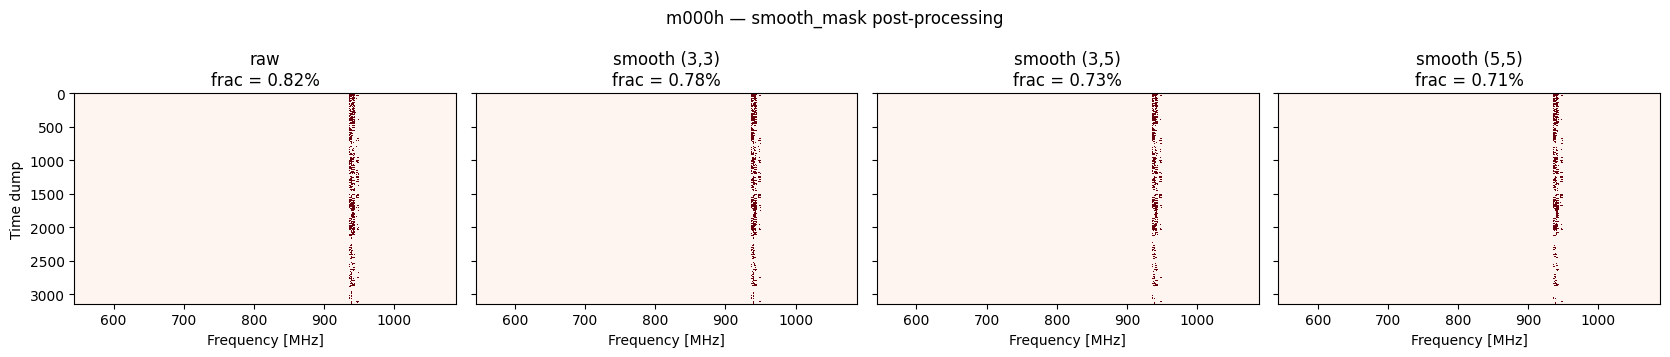

In [13]:
smooth_results = {
    "raw":          mask_default_a.copy(),
    "smooth (3,3)": smooth_mask(mask_default_a, kernel_size=(3, 3)),
    "smooth (3,5)": smooth_mask(mask_default_a, kernel_size=(3, 5)),
    "smooth (5,5)": smooth_mask(mask_default_a, kernel_size=(5, 5)),
}
for lbl, m in smooth_results.items():
    print(f"{lbl:<15s}  flag fraction = {mask_frac(m):.2%}")

scenarios_a["smoothed (3,5)"] = smooth_results["smooth (3,5)"]

plot_mask_grid(list(smooth_results.values()), list(smooth_results.keys()),
               freqs_hz / 1e6, suptitle=f"{NAME_A} — smooth_mask post-processing")


## 11. Dead-band channel prior

AOflagger's ~34 % mask is dominated by **structural cuts**: whole
frequency bands flagged at every time dump (GSM / LTE / navigation /
aviation bands, plus some receiver-specific dead channels). These are
obvious if we compute the AOflagger flag fraction *per channel* — dead
bands show up as plateaus at ~100 %.

Those whole-channel cuts are something no waterfall-residual flagger can
reproduce. A fairer test of what MomentRFI *adds* is to:

1. Pick out the dead channels (flag fraction ≥ threshold, default 90 %).
2. Build a channel-level `prior_mask` — True for every pixel in a dead
   channel, False elsewhere.
3. Run MomentRFI with that prior. The fitter excludes dead channels from
   the polynomial fit (a much cleaner bandpass) and hunts for per-pixel
   RFI in the remaining channels.

The `added vs AO` quantity becomes interesting here: it is exactly the
pixels in non-dead channels that MomentRFI flags but AOflagger did
not.

m000h: dead channels (≥ 90%) : 901 / 4096  (22.00% of band)


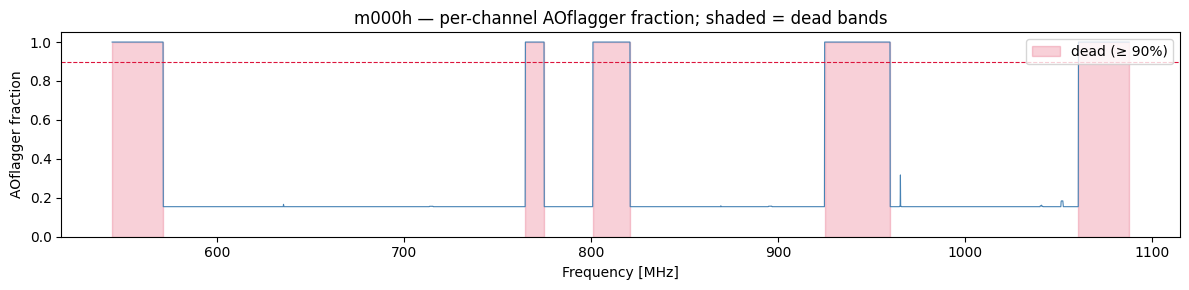

In [14]:
DEAD_THRESH = 0.90

ao_frac_ch_a = ao_a.mean(axis=0)          # (n_freq,)  per-channel AO fraction
dead_ch_a    = ao_frac_ch_a >= DEAD_THRESH

print(f"{NAME_A}: dead channels (≥ {DEAD_THRESH:.0%}) : "
      f"{dead_ch_a.sum()} / {len(dead_ch_a)}  "
      f"({dead_ch_a.mean():.2%} of band)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(freqs_hz / 1e6, ao_frac_ch_a, color="steelblue", lw=0.8)
ax.fill_between(freqs_hz / 1e6, 0, 1, where=dead_ch_a,
                color="crimson", alpha=0.2, label=f"dead (≥ {DEAD_THRESH:.0%})")
ax.axhline(DEAD_THRESH, ls="--", color="crimson", lw=0.8)
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("AOflagger fraction")
ax.set_title(f"{NAME_A} — per-channel AOflagger fraction; shaded = dead bands")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [15]:
# Build the channel-level prior mask and run MomentRFI with it at three σ values.
ch_prior_a = np.broadcast_to(dead_ch_a[None, :], ao_a.shape).copy()

cprior_runs_a = {}
for s in [1.0, 1.5, 4.0]:
    fit_cp, mask_cp = run_scenario(wf_a, prior_mask=ch_prior_a, sigma_threshold=s)
    cprior_runs_a[s] = (fit_cp, mask_cp)
    inter = (mask_cp & ao_a).sum()
    print(f"\u03c3 = {s:>3.1f}  frac = {mask_frac(mask_cp):.2%}   "
          f"new outside dead ch = {(mask_cp & ~ch_prior_a).mean():.2%}   "
          f"recall vs AO = {inter/ao_a.sum():.2%}   "
          f"precision vs AO = {inter/mask_cp.sum() if mask_cp.any() else 0:.2%}   "
          f"added = {(mask_cp & ~ao_a).mean():.2%}")

# Keep the default-σ channel-prior result as the canonical scenario.
fit_chprior_a, mask_chprior_a = cprior_runs_a[4.0]
scenarios_a["channel prior"] = mask_chprior_a


σ = 1.0  frac = 32.38%   new outside dead ch = 10.39%   recall vs AO = 89.49%   precision vs AO = 94.09%   added = 1.91%


σ = 1.5  frac = 30.27%   new outside dead ch = 8.27%   recall vs AO = 88.41%   precision vs AO = 99.45%   added = 0.17%


σ = 4.0  frac = 22.00%   new outside dead ch = 0.00%   recall vs AO = 64.60%   precision vs AO = 100.00%   added = 0.00%


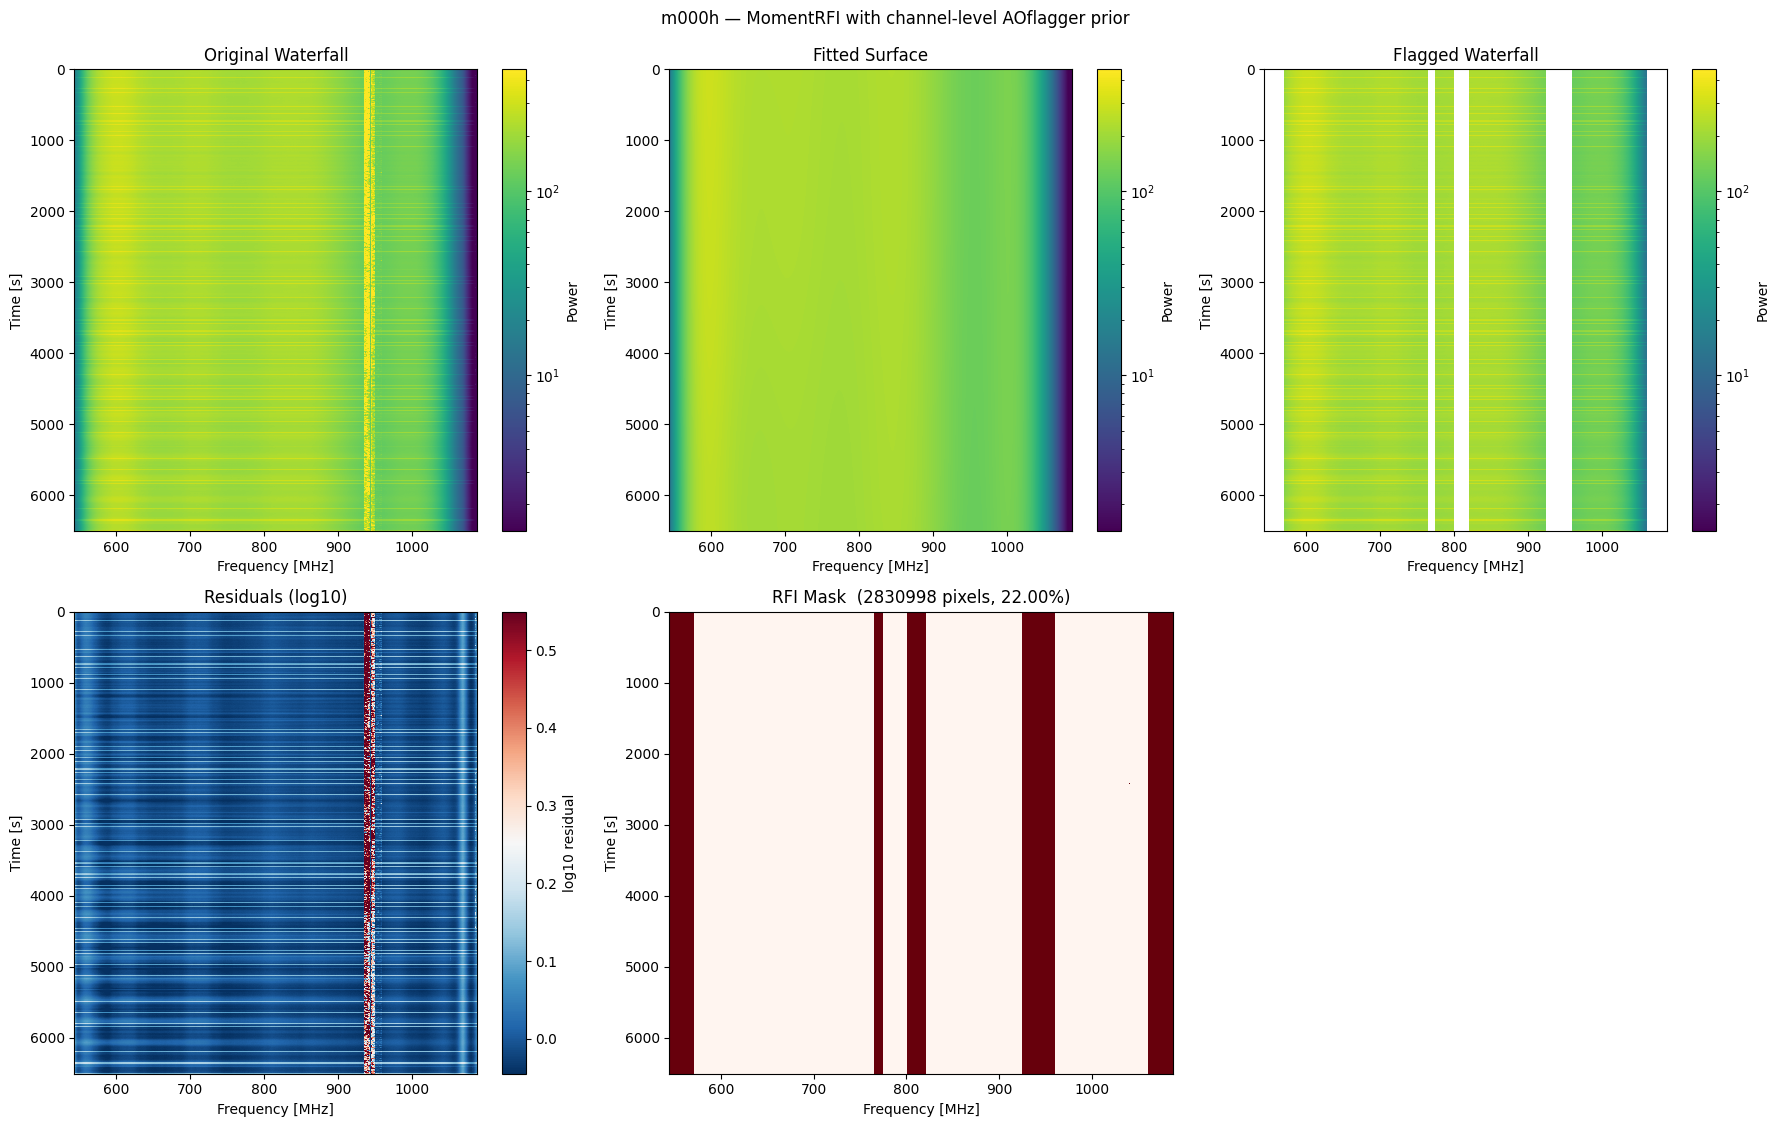

In [16]:
plot_summary(wf_a, fit_chprior_a, freqs=freqs_hz / 1e6, times=times_s - times_s[0])
plt.suptitle(f"{NAME_A} — MomentRFI with channel-level AOflagger prior", y=1.02)
plt.show()


## 12. Stressed receiver replay — `m034h`

Repeat the default fit and the two `sigma_threshold` extremes on the
heavily-flagged receiver, and store the results for the final AOflagger
comparison. The Phase 1 sigma floor is the safeguard here: a dirtier Phase
1 residual raises the floor used in Phase 2.

In [17]:
i_b = receiver_index_of(NAME_B)
wf_b, ao_b = prepare_waterfall(i_b)

# Channel-level prior for m034h, same DEAD_THRESH as m000h
ao_frac_ch_b = ao_b.mean(axis=0)
dead_ch_b    = ao_frac_ch_b >= DEAD_THRESH
ch_prior_b   = np.broadcast_to(dead_ch_b[None, :], ao_b.shape).copy()

print(f"{NAME_B}: dead channels (≥ {DEAD_THRESH:.0%}) : "
      f"{dead_ch_b.sum()} / {len(dead_ch_b)}  "
      f"({dead_ch_b.mean():.2%} of band)")

fit_default_b,  mask_default_b  = run_scenario(wf_b)
fit_aggr_b,     mask_aggr_b     = run_scenario(wf_b, sigma_threshold=1.0)
fit_cons_b,     mask_cons_b     = run_scenario(wf_b, sigma_threshold=4.0)

# Channel-prior fits at three sigma values, matching m000h.
cprior_runs_b = {}
for s in [1.0, 1.5, 4.0]:
    fit_cp, mask_cp = run_scenario(wf_b, prior_mask=ch_prior_b, sigma_threshold=s)
    cprior_runs_b[s] = (fit_cp, mask_cp)
fit_chprior_b, mask_chprior_b = cprior_runs_b[4.0]

mask_smooth_b = smooth_mask(mask_default_b, kernel_size=(3, 5))

scenarios_b = {
    "default":              mask_default_b,
    "aggressive (σ=1.0)":    mask_aggr_b,
    "conservative (σ=4.0)":  mask_cons_b,
    "smoothed (3,5)":       mask_smooth_b,
    "channel prior":        mask_chprior_b,
}
for lbl, m in scenarios_b.items():
    print(f"{lbl:<22s}  flag fraction = {mask_frac(m):.2%}")

print(f"\nsigma_floor (default fit)      = {fit_default_b.sigma_floor:.4f}")
print(f"sigma_floor (aggressive fit)   = {fit_aggr_b.sigma_floor:.4f}")
print(f"sigma_floor (conservative fit) = {fit_cons_b.sigma_floor:.4f}")
print(f"sigma_floor (chprior fit)      = {fit_chprior_b.sigma_floor:.4f}")


m034h: dead channels (≥ 90%) : 902 / 4096  (22.02% of band)


default                 flag fraction = 1.95%
aggressive (σ=1.0)      flag fraction = 13.41%
conservative (σ=4.0)    flag fraction = 1.95%
smoothed (3,5)          flag fraction = 1.93%
channel prior           flag fraction = 22.02%

sigma_floor (default fit)      = 0.1517
sigma_floor (aggressive fit)   = 0.0760
sigma_floor (conservative fit) = 0.1517
sigma_floor (chprior fit)      = 0.0600


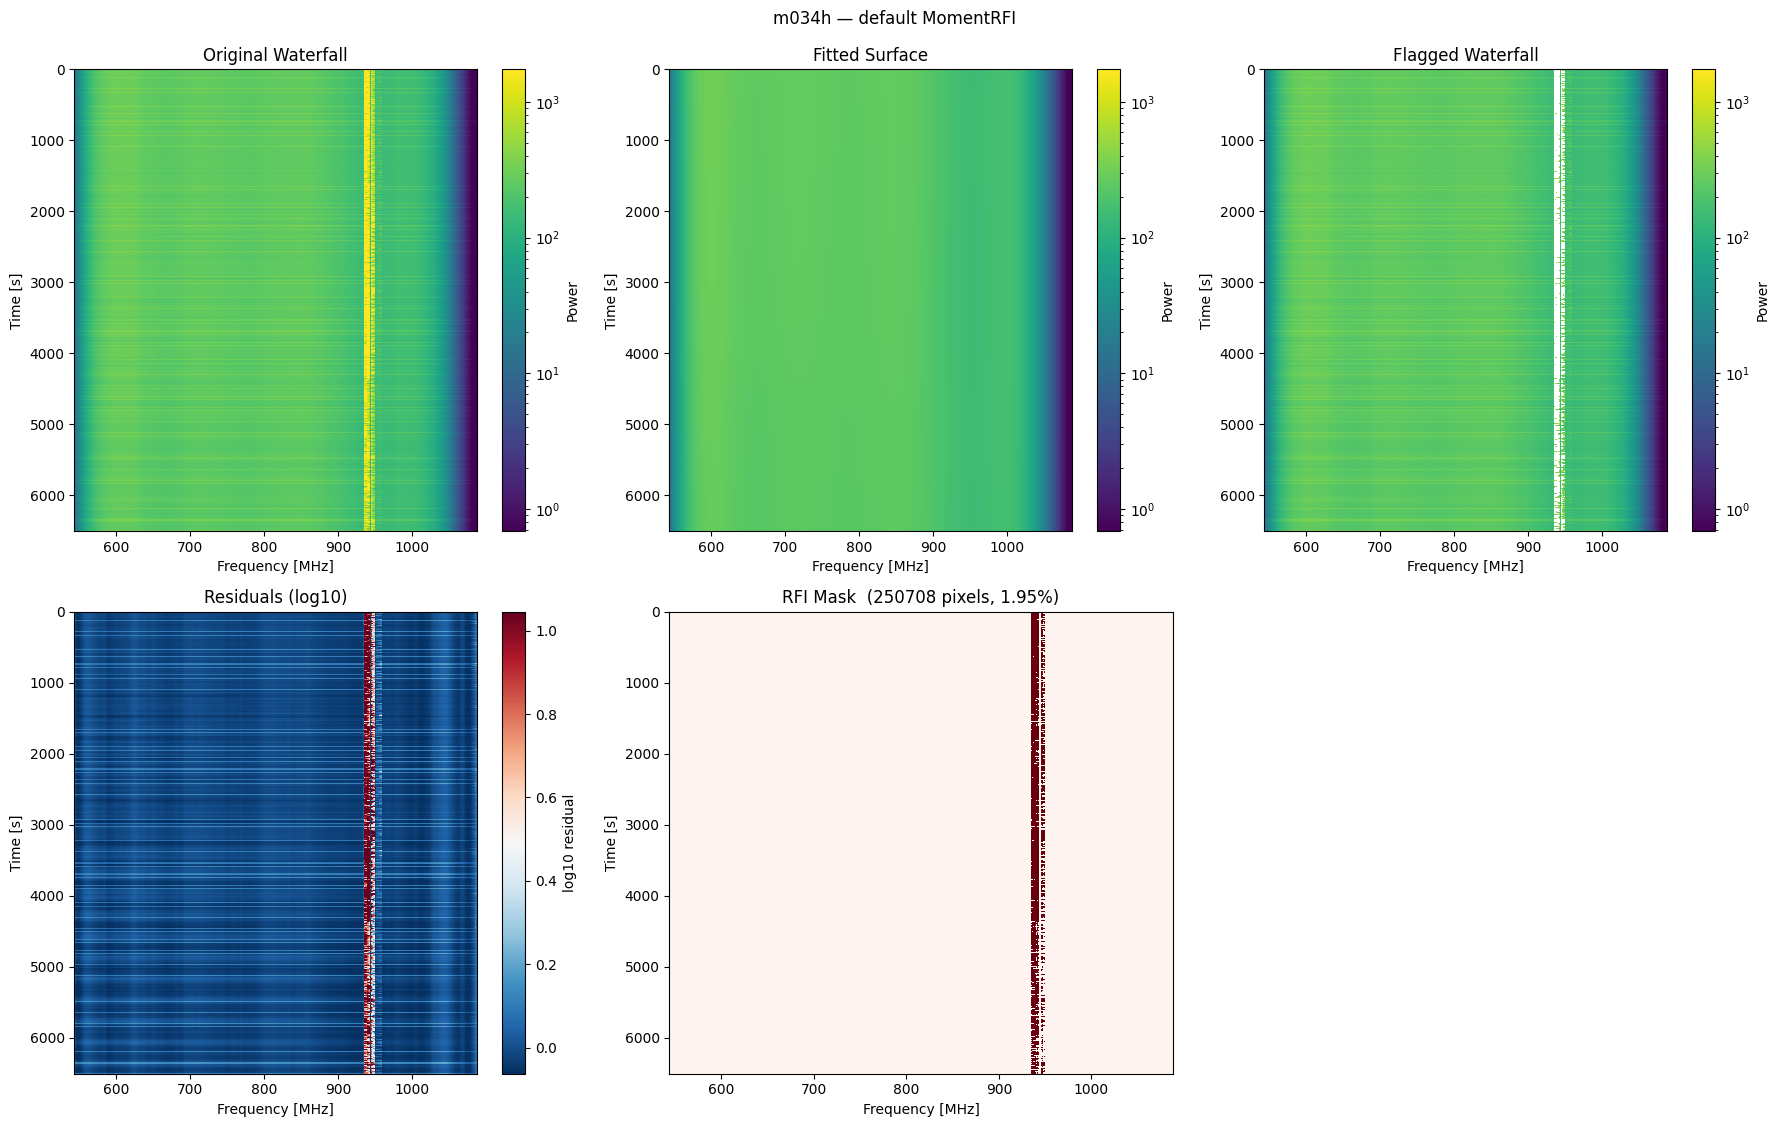

In [18]:
plot_summary(wf_b, fit_default_b, freqs=freqs_hz / 1e6, times=times_s - times_s[0])
plt.suptitle(f"{NAME_B} — default MomentRFI", y=1.02)
plt.show()


## 13. Comparison against AOflagger

This is the only place where we bring the MeerKLASS first-round AOflagger
mask back into the picture. The framing is: **given that AOflagger is a
kitchen-sink mask (combining known-RFI channel cuts, noise-diode time cuts,
point-source flags, and a waterfall pass), how much of it can a pure
waterfall-based flagger like MomentRFI independently recover?**

The metrics:

- `frac` — flag fraction of this scenario
- `recall vs AO` = `|MRFI ∩ AO| / |AO|` — fraction of AO-flagged pixels
  that MomentRFI also flags (higher = more of AO is waterfall-recoverable)
- `precision vs AO` = `|MRFI ∩ AO| / |MRFI|` — fraction of MomentRFI's
  flags that AO agrees with (higher = fewer false positives relative to AO)
- `added` = `|MRFI \ AO| / N` — fraction of pixels MomentRFI flags that AO
  did not. **If `added` is always 0, MomentRFI is a strict subset of AO**
  — i.e. AO catches everything MomentRFI catches plus more.


In [19]:
def compare_vs_ao(ao_mask, scenarios):
    """scenarios: list of (sigma, prior_label, mask) tuples."""
    ao_n = ao_mask.sum()
    rows = [("—", "—", mask_frac(ao_mask), 1.0, 1.0, 0.0, "AOflagger")]
    for s, p, m in scenarios:
        inter  = (m & ao_mask).sum()
        recall = inter / ao_n if ao_n else 0.0
        prec   = inter / m.sum() if m.any() else 0.0
        added  = (m & ~ao_mask).mean()
        rows.append((s, p, mask_frac(m), recall, prec, added, "MomentRFI"))
    return rows


def print_table(rows, title):
    print(title)
    print(f"{'source':<11s}  {'σ':>4s}  {'prior':>8s}  "
          f"{'frac':>7s}  {'recall':>7s}  {'precision':>9s}  {'added':>7s}")
    print("-" * 66)
    for r in rows:
        s, p, frac, rec, pre, add, src = r
        s_str = s if isinstance(s, str) else f"{s:.1f}"
        print(f"{src:<11s}  {s_str:>4}  {p:>8s}  "
              f"{frac:>7.2%}  {rec:>7.2%}  {pre:>9.2%}  {add:>7.2%}")
    print()


In [20]:
final_a = [
    (1.0, "none",    scenarios_a["aggressive (σ=1.0)"]),
    (4.0, "none",    scenarios_a["default"]),
    (1.0, "channel", cprior_runs_a[1.0][1]),
    (1.5, "channel", cprior_runs_a[1.5][1]),
    (4.0, "channel", cprior_runs_a[4.0][1]),
]
final_b = [
    (1.0, "none",    scenarios_b["aggressive (σ=1.0)"]),
    (4.0, "none",    scenarios_b["default"]),
    (1.0, "channel", cprior_runs_b[1.0][1]),
    (1.5, "channel", cprior_runs_b[1.5][1]),
    (4.0, "channel", cprior_runs_b[4.0][1]),
]

rows_a = compare_vs_ao(ao_a, final_a)
rows_b = compare_vs_ao(ao_b, final_b)
print_table(rows_a, f"=== {NAME_A} ===")
print_table(rows_b, f"=== {NAME_B} ===")


=== m000h ===
source          σ     prior     frac   recall  precision    added
------------------------------------------------------------------
AOflagger       —         —   34.05%  100.00%    100.00%    0.00%
MomentRFI     1.0      none   13.22%   38.83%    100.00%    0.00%
MomentRFI     4.0      none    0.82%    2.39%    100.00%    0.00%
MomentRFI     1.0   channel   32.38%   89.49%     94.09%    1.91%
MomentRFI     1.5   channel   30.27%   88.41%     99.45%    0.17%
MomentRFI     4.0   channel   22.00%   64.60%    100.00%    0.00%

=== m034h ===
source          σ     prior     frac   recall  precision    added
------------------------------------------------------------------
AOflagger       —         —   34.10%  100.00%    100.00%    0.00%
MomentRFI     1.0      none   13.41%   39.32%    100.00%    0.00%
MomentRFI     4.0      none    1.95%    5.71%    100.00%    0.00%
MomentRFI     1.0   channel   32.24%   89.40%     94.54%    1.76%
MomentRFI     1.5   channel   31.25%   88.96%

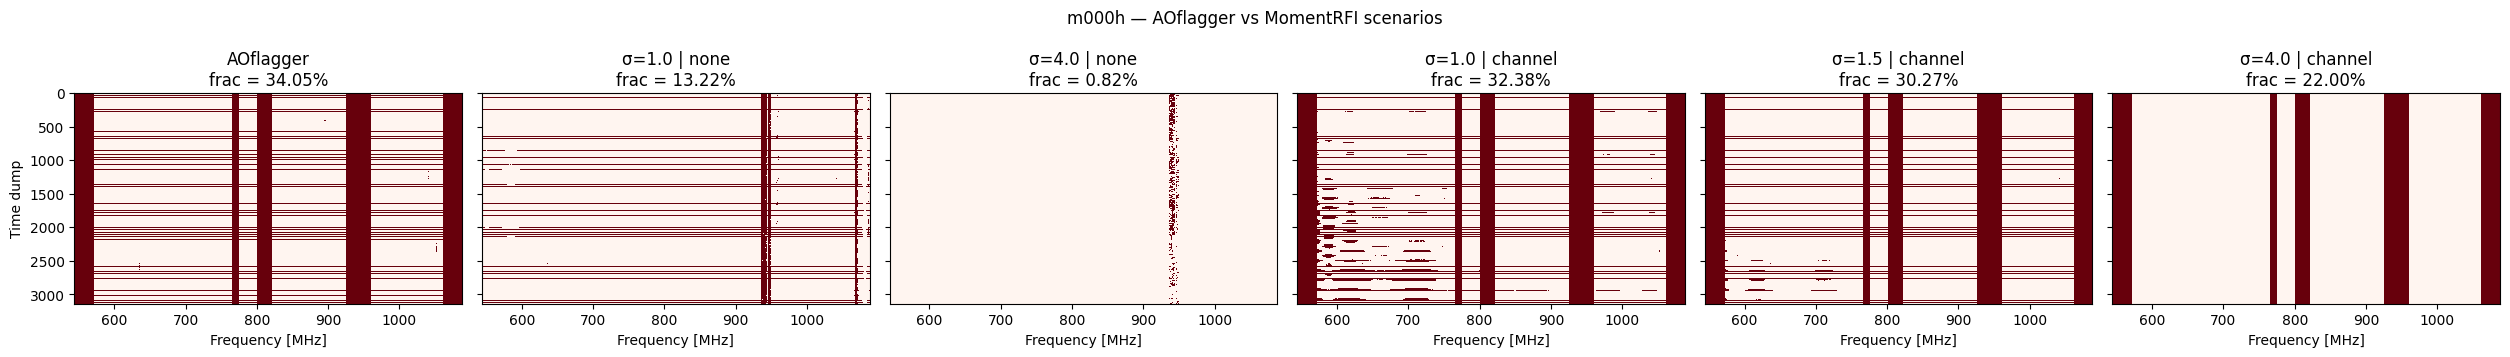

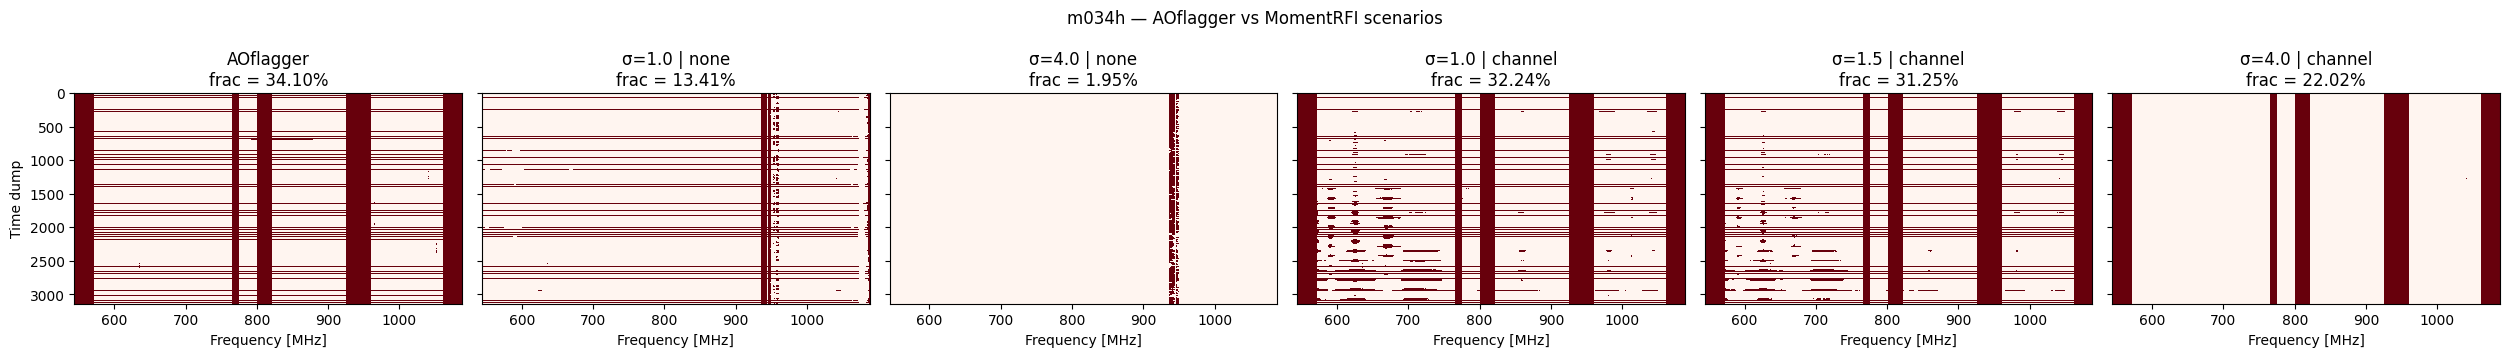

In [21]:
# Visual side-by-side: AOflagger first, then each MomentRFI scenario.
def _fmt(s, p):
    return f"σ={s:.1f} | {p}"

labels_a = ["AOflagger"] + [_fmt(s, p) for s, p, _ in final_a]
masks_a  = [ao_a] + [m for _, _, m in final_a]
plot_mask_grid(masks_a, labels_a, freqs_hz / 1e6,
               suptitle=f"{NAME_A} — AOflagger vs MomentRFI scenarios",
               ncols=len(masks_a))

labels_b = ["AOflagger"] + [_fmt(s, p) for s, p, _ in final_b]
masks_b  = [ao_b] + [m for _, _, m in final_b]
plot_mask_grid(masks_b, labels_b, freqs_hz / 1e6,
               suptitle=f"{NAME_B} — AOflagger vs MomentRFI scenarios",
               ncols=len(masks_b))


### Reading the table

Each MomentRFI row is labelled by its two free knobs: **`σ`** (sigma
threshold) and **`prior`** (either `none`, meaning fit the whole
waterfall, or `channel`, meaning the dead frequency bands identified in
§11 are held fixed and excluded from the polynomial fit).

The table is a 2 × K grid:

- `σ = 4.0, prior = none` is the MomentRFI default.
- `σ = 1.0, prior = none` shows how aggressive a from-scratch fit has
  to be to start recovering AO.
- `σ = 4.0, prior = channel` shows the cleanest fit possible at default
  `σ`: dead bands excised, polynomial fits just the clean channels.
- `σ ∈ {1.0, 1.5}, prior = channel` pushes aggressiveness on top of the
  cleanest fit — MomentRFI's best-case configuration for discovering
  RFI that AOflagger missed.

Watch the `added` column across the bottom three rows. If any of them
jumps above 0 %, MomentRFI *is* finding per-pixel RFI in the clean bands
that AOflagger missed. If they are all still 0 %, MomentRFI contributes
nothing beyond AO even in its best configuration on these receivers.

### Suggested follow-ups

1. Loop this scenario set over all 128 receivers and plot `recall vs AO`
   distributions per scenario — a one-slide performance summary.
2. Use `fit.history` (Phase 1 / Phase 2 iteration dicts) to flag receivers
   that hit `max_iterations` — those are candidates for parameter tuning.
3. Check whether any MomentRFI-added pixels (in scenarios where `added
   > 0`) land near known astronomical sources — those are false
   positives worth auditing.